# 第七讲：时间序列预测、LSTM 与灰色预测

本 Notebook 按照当前授课主线组织：先理解时间序列预测问题，再建立平滑模型和 ARIMA 思路；随后用 LSTM 展示单变量滑动窗口序列预测，最后介绍适合小样本趋势预测的 GM(1,1)。

本讲重点不是堆叠模型名称，而是让每个模型都能回答清楚三个问题：它利用了什么时间信息，误差表现如何，论文中应如何解释。

## 1. 导入库与基础设置

时间序列是一组按时间顺序排列的数据：

$$
y_1,y_2,\ldots,y_t,\ldots,y_T
$$

预测任务是根据历史观测值估计未来值：

$$
\hat y_{T+1},\hat y_{T+2},\ldots,\hat y_{T+h}
$$

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'Arial Unicode MS']
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('第七讲示例数据.csv')
GM_DATA_PATH = Path('第七讲GM11示例数据.csv')
OUT_DIR = Path('第七讲_outputs')
OUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)

## 2. 读取月度用电量数据

先处理单变量时间序列。图中主要观察趋势、季节波动和异常点。

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df['月份'] = pd.to_datetime(df['月份'])  #把“月份”这一列转化为时间索引
df = df.sort_values('月份').reset_index(drop=True)
series = df.set_index('月份')['用电量'].asfreq('MS')

print('数据起止时间：', series.index.min().date(), '至', series.index.max().date())
print('样本数量：', len(series))
df.head()

数据起止时间： 2021-01-01 至 2025-12-01
样本数量： 60


,月份,用电量
0,2021-01-01,519.88
1,2021-02-01,525.34
2,2021-03-01,549.35
3,2021-04-01,580.14
4,2021-05-01,572.93


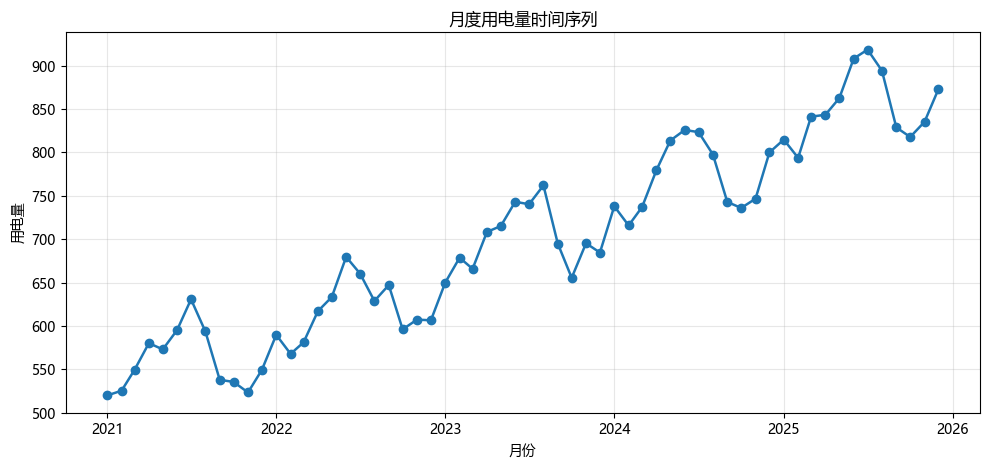

In [3]:
plt.figure(figsize=(10, 4.8))
plt.plot(series.index, series.values, marker='o', linewidth=1.8)
plt.title('月度用电量时间序列')
plt.xlabel('月份')
plt.ylabel('用电量')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '月度用电量时间序列.png', dpi=160)
plt.show()

### 2.1 时间序列的四种常见成分

观察时间序列时，通常从四类成分入手：

- 趋势：长期上升或下降方向；
- 季节性：固定周期内重复出现的波动；
- 周期：不一定固定长度的长期波动；
- 随机扰动：无法完全解释的偶然变化。

本讲的月度用电量序列既有长期增长，也有月度波动。后续模型的区别，正体现在它们分别如何处理趋势、季节性、自相关和随机误差。

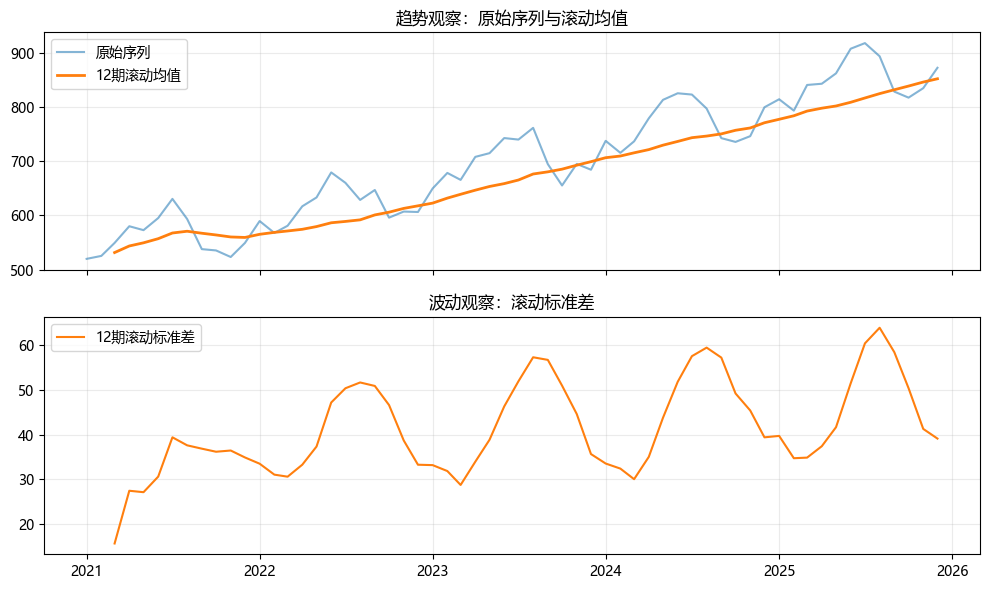

In [4]:
component_view = pd.DataFrame({
    '原始序列': series,
    '12期滚动均值': series.rolling(12, min_periods=3).mean(),
    '12期滚动标准差': series.rolling(12, min_periods=3).std()
})

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(component_view.index, component_view['原始序列'], label='原始序列', alpha=0.55)
axes[0].plot(component_view.index, component_view['12期滚动均值'], label='12期滚动均值', linewidth=2)
axes[0].set_title('趋势观察：原始序列与滚动均值')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(component_view.index, component_view['12期滚动标准差'], color='tab:orange', label='12期滚动标准差')
axes[1].set_title('波动观察：滚动标准差')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / '时间序列成分观察.png', dpi=160)
plt.show()

In [5]:
test_size = 6
train_series = series.iloc[:-test_size]
test_series = series.iloc[-test_size:]

print('训练集：', train_series.index.min().date(), '至', train_series.index.max().date())
print('测试集：', test_series.index.min().date(), '至', test_series.index.max().date())

训练集： 2021-01-01 至 2025-06-01
测试集： 2025-07-01 至 2025-12-01


## 3. 训练集与测试集

时间序列不能随机打乱。这里保留最后 6 个月作为测试集，用前面的月份预测后面的月份。

## 4. 基准模型：朴素预测、移动平均与指数平滑

指数平滑的递推形式为：

$$
\hat y_{t+1}=\alpha y_t+(1-\alpha)\hat y_t
$$

简单模型是重要参照。如果复杂模型没有明显优于简单模型，结论中应当说明原因。

### 4.1 先定义误差指标

后面所有预测模型都使用同一组指标评价：MAE、RMSE 和 MAPE。MAPE 是百分比误差，便于解释，但当真实值接近 0 时不稳定。

In [6]:
def forecast_metrics(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAPE_%': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }

### 4.2 建立三个简单基线模型

朴素预测用最后一个训练值代表未来；移动平均用最近几期平均值；指数平滑则让近期数据权重更高。它们是后面复杂模型的参照线。

In [7]:
naive_forecast = pd.Series(train_series.iloc[-1], index=test_series.index)
ma_forecast = pd.Series(train_series.tail(3).mean(), index=test_series.index)
exp_forecast = pd.Series(train_series.ewm(alpha=0.35, adjust=False).mean().iloc[-1], index=test_series.index)

### 4.3 画出平滑曲线

这张图用于观察平滑方法如何削弱短期波动。注意，曲线更平滑不代表预测一定更准确，最终还要看测试集误差。

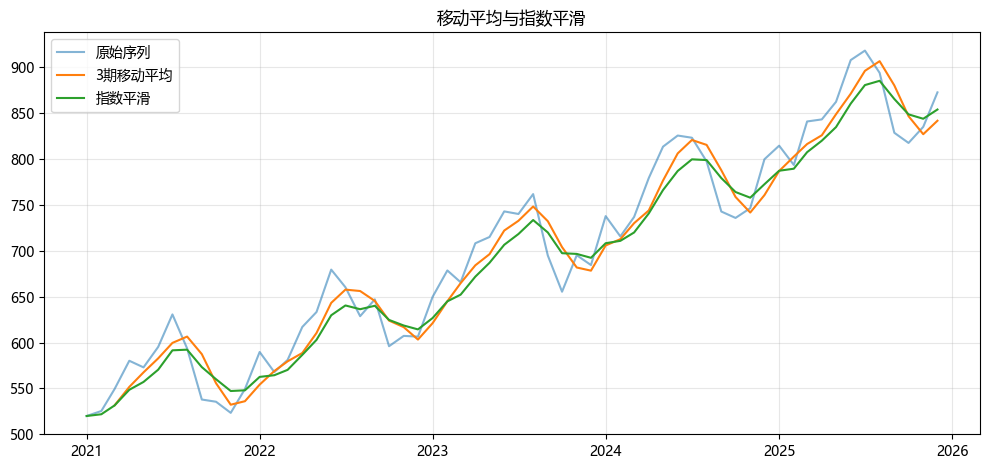

In [8]:
plt.figure(figsize=(10, 4.8))
plt.plot(series.index, series.values, alpha=0.55, label='原始序列')
plt.plot(series.index, series.rolling(3).mean(), label='3期移动平均')
plt.plot(series.index, series.ewm(alpha=0.35, adjust=False).mean(), label='指数平滑')
plt.title('移动平均与指数平滑')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '移动平均与指数平滑.png', dpi=160)
plt.show()

## 5. ARIMA 思路：平稳性、差分与自回归

ARIMA 常写作 ARIMA$(p,d,q)$，其中：

- $p$：自回归阶数，表示使用多少期过去值；
- $d$：差分次数，用于把趋势转化为相对稳定的变化量；
- $q$：移动平均阶数，表示使用多少期过去误差进行。

由于当前环境中的 `statsmodels` 二进制依赖不稳定，这里采用一个可直接运行的 ARIMA$(p,1,0)$ 思路：先做一阶差分，再用过去 $p$ 期差分建立自回归模型。预测时再加入去年同月和最近一年平均增长量，帮助处理月度季节波动。


### 5.1 平稳性、差分与相关结构

ARIMA 建模前要先看序列是否相对平稳。直观判断可看滚动均值和滚动标准差；若序列长期上升，通常需要差分。

一阶差分为：

$$
\Delta y_t=y_t-y_{t-1}
$$

ACF 用来观察 $y_t$ 与 $y_{t-k}$ 的总体相关，PACF 用来观察控制中间滞后后某一阶滞后的直接相关。它们不是最终答案，但能帮助理解序列记忆长度。

### 5.1.1 计算 ACF 与 PACF

这里用差分后的序列计算相关结构。PACF 用线性回归近似得到，目的是帮助学生理解“控制中间滞后后”的直接相关。

In [9]:
def partial_autocorr_by_lag(values, max_lag):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    pacf = []
    for lag in range(1, max_lag + 1):
        y_lag = values[lag:]
        X_lag = np.column_stack([values[lag - j - 1: len(values) - j - 1] for j in range(lag)])
        model = LinearRegression().fit(X_lag, y_lag)
        pacf.append(model.coef_[-1])
    return pacf


diff_train = train_series.diff().dropna()
acf_values = [diff_train.autocorr(lag=lag) for lag in range(1, 13)]
pacf_values = partial_autocorr_by_lag(diff_train, 12)

### 5.1.2 可视化相关结构

左图是 ACF，右图是 PACF。若某些滞后阶数相关明显，说明历史值对当前值仍有信息。

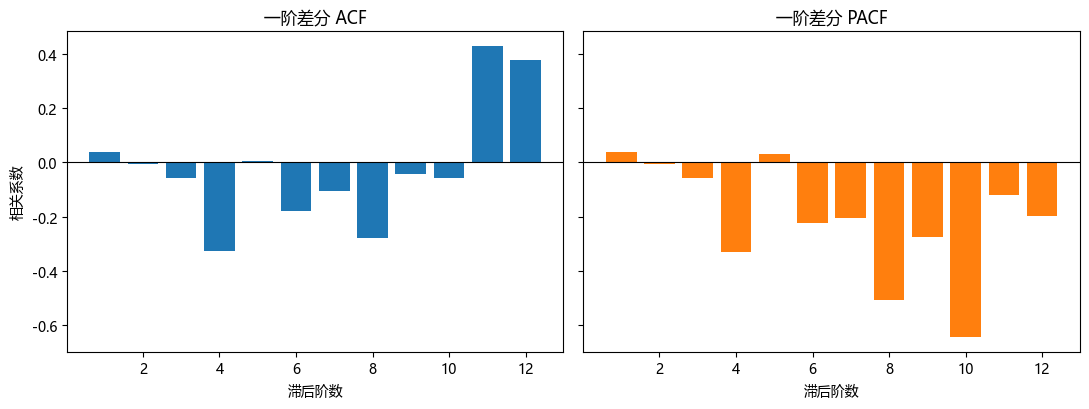

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
axes[0].bar(range(1, 13), acf_values)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('一阶差分 ACF')
axes[0].set_xlabel('滞后阶数')
axes[0].set_ylabel('相关系数')

axes[1].bar(range(1, 13), pacf_values, color='tab:orange')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('一阶差分 PACF')
axes[1].set_xlabel('滞后阶数')

plt.tight_layout()
plt.savefig(OUT_DIR / '一阶差分ACF_PACF示意图.png', dpi=160)
plt.show()

In [11]:
lag_diagnostics = pd.DataFrame({
    '滞后阶数': range(1, 13),
    'ACF': acf_values,
    'PACF近似': pacf_values
})
lag_diagnostics.round(3)

,滞后阶数,ACF,PACF近似
0,1,0.039,0.039
1,2,-0.006,-0.007
2,3,-0.057,-0.058
3,4,-0.325,-0.331
4,5,0.006,0.032
5,6,-0.177,-0.222
6,7,-0.106,-0.203
7,8,-0.276,-0.507
8,9,-0.044,-0.274
9,10,-0.059,-0.643


### 5.3 定义 ARIMA$(p,1,0)$ 的简化拟合函数

这个函数先对序列做一阶差分，再用过去 $p$ 期差分预测当前差分，并用 AIC 比较不同阶数。

In [12]:
def fit_arima_p10(train, p):
    diff_values = train.diff().dropna().values
    X_lag, y_lag = [], []
    for i in range(p, len(diff_values)):
        X_lag.append(diff_values[i-p:i][::-1])
        y_lag.append(diff_values[i])
    X_lag = np.array(X_lag)
    y_lag = np.array(y_lag)
    model = LinearRegression().fit(X_lag, y_lag)
    fitted = model.predict(X_lag)
    rss = np.sum((y_lag - fitted) ** 2)
    n = len(y_lag)
    k = p + 2
    aic = n * np.log(max(rss / n, 1e-8)) + 2 * k
    return model, aic

### 5.4 定义滚动预测函数

滚动预测遵守“用过去预测未来”的原则。预测一个月后，将真实测试值补入历史序列，再预测下一个月。

In [13]:
def rolling_forecast_arima_p10(train, test, model, p, seasonal_weight=0.65):
    history = train.copy()
    preds = []
    for date, actual in test.items():
        diff_values = history.diff().dropna().values
        lag_features = np.array(diff_values[-p:][::-1]).reshape(1, -1)
        arima_level = history.iloc[-1] + float(model.predict(lag_features)[0])

        same_month_last_year = date - pd.DateOffset(years=1)
        if same_month_last_year in history.index:
            recent_growth = history.diff(12).dropna().tail(6).mean()
            if pd.isna(recent_growth):
                recent_growth = history.diff().tail(6).mean() * 12
            seasonal_level = history.loc[same_month_last_year] + recent_growth
            arima_level = seasonal_weight * seasonal_level + (1 - seasonal_weight) * arima_level
        preds.append(arima_level)
        history.loc[date] = actual
    return pd.Series(preds, index=test.index)

### 5.5 选择阶数并预测测试集

这里比较 $p=1,2,3$ 的 AIC。AIC 较小表示在拟合误差和模型复杂度之间更平衡。

In [14]:
fit_rows = []
best_arima_model = None
best_order = None
best_aic = np.inf

for p in [1, 2, 3]:
    model_p, aic_p = fit_arima_p10(train_series, p)
    fit_rows.append({'order': f'ARIMA({p},1,0)+季节调整', 'AIC': aic_p})
    if aic_p < best_aic:
        best_aic = aic_p
        best_order = (p, 1, 0)
        best_arima_model = model_p

arima_search = pd.DataFrame(fit_rows).sort_values('AIC').reset_index(drop=True)
arima_forecast = rolling_forecast_arima_p10(train_series, test_series, best_arima_model, best_order[0])
arima_search

,order,AIC
0,"ARIMA(3,1,0)+季节调整",353.199444
1,"ARIMA(2,1,0)+季节调整",357.796256
2,"ARIMA(1,1,0)+季节调整",361.951334


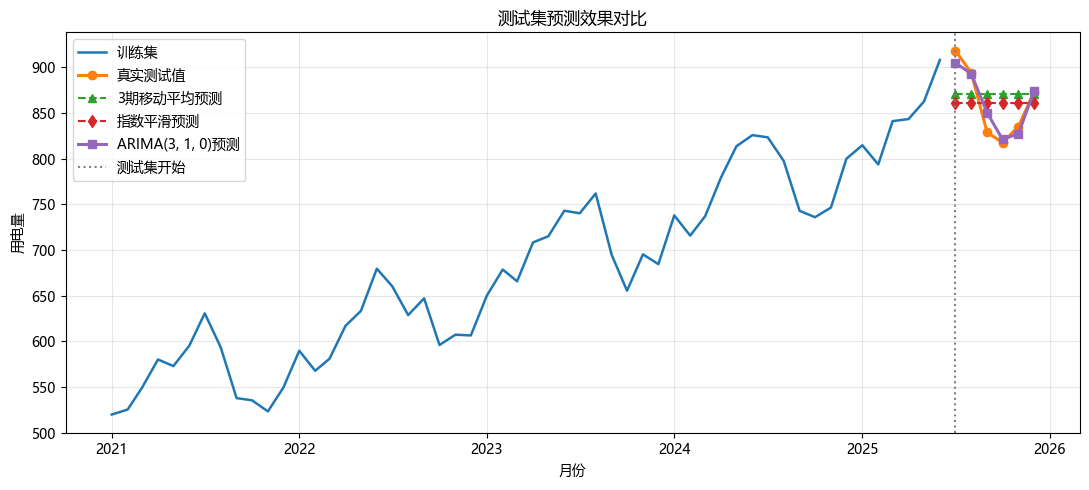

In [15]:
plt.figure(figsize=(11, 5))
plt.plot(train_series.index, train_series.values, label='训练集', linewidth=1.8)
plt.plot(test_series.index, test_series.values, marker='o', label='真实测试值', linewidth=2.2)
plt.plot(test_series.index, ma_forecast.values, marker='^', linestyle='--', label='3期移动平均预测')
plt.plot(test_series.index, exp_forecast.values, marker='d', linestyle='--', label='指数平滑预测')
plt.plot(test_series.index, arima_forecast.values, marker='s', linewidth=2.2, label=f'ARIMA{best_order}预测')
plt.axvline(test_series.index[0], color='gray', linestyle=':', label='测试集开始')
plt.title('测试集预测效果对比')
plt.xlabel('月份')
plt.ylabel('用电量')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '测试集预测效果对比.png', dpi=160)
plt.show()

In [16]:
single_models = {
    '朴素预测': naive_forecast,
    '3期移动平均': ma_forecast,
    '指数平滑': exp_forecast,
    f'ARIMA{best_order}': arima_forecast,
}

metric_df = pd.DataFrame([
    {'模型': name, **forecast_metrics(test_series, pred)}
    for name, pred in single_models.items()
]).sort_values('RMSE').reset_index(drop=True)

metric_df.to_csv(OUT_DIR / '单变量预测误差对比.csv', index=False, encoding='utf-8-sig')
metric_df.round(3)

,模型,MAE,RMSE,MAPE_%
0,"ARIMA(3, 1, 0)",7.968,10.883,0.932
1,指数平滑,33.950,36.773,3.929
2,3期移动平均,33.950,38.146,3.978
3,朴素预测,50.350,59.602,6.012


### 5.6 残差诊断

残差为真实值与预测值之差：

$$
e_t=y_t-\hat y_t
$$

理想情况下，残差应围绕 0 随机波动；如果残差仍有明显趋势、周期或连续偏正偏负，说明模型可能漏掉了结构信息。

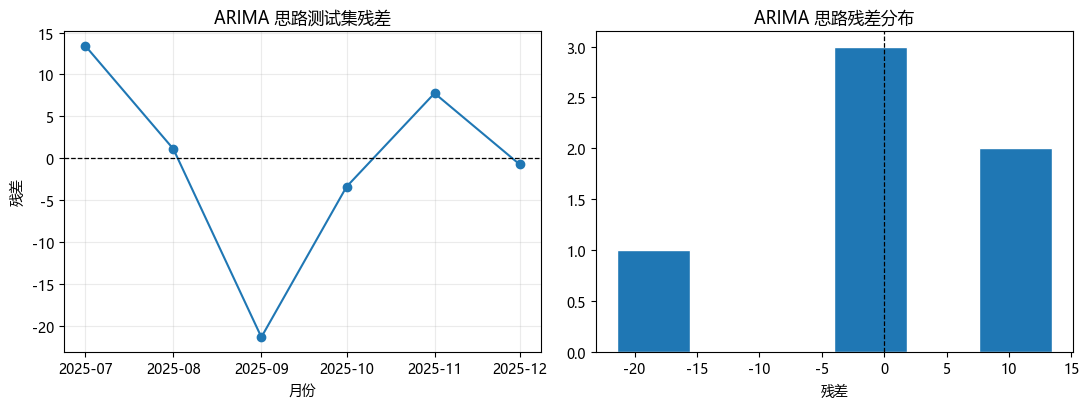

,残差均值,残差标准差,残差最大绝对值
0,-0.546,11.907,21.381


In [17]:
arima_residual = test_series - arima_forecast

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(arima_residual.index, arima_residual.values, marker='o')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.9)
axes[0].set_title('ARIMA 思路测试集残差')
axes[0].set_xlabel('月份')
axes[0].set_ylabel('残差')
axes[0].grid(alpha=0.25)

axes[1].hist(arima_residual.values, bins=6, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.9)
axes[1].set_title('ARIMA 思路残差分布')
axes[1].set_xlabel('残差')

plt.tight_layout()
plt.savefig(OUT_DIR / 'ARIMA残差诊断.png', dpi=160)
plt.show()

pd.DataFrame({
    '残差均值': [arima_residual.mean()],
    '残差标准差': [arima_residual.std()],
    '残差最大绝对值': [arima_residual.abs().max()]
}).round(3)

## 6. LSTM 序列模型


LSTM 的输入是过去 $L$ 期用电量，输出是下一期用电量：

$$
X_t=[y_{t-L+1},y_{t-L+2},\ldots,y_t],\quad target=y_{t+1}
$$

它适合展示“历史窗口如何变成监督学习样本”。由于样本量不大，本讲把 LSTM 作为拓展模型，与平滑模型和 ARIMA 思路进行误差比较。

### 6.1 准备单变量序列窗口

神经网络对量纲敏感。这里只用训练集估计标准化参数，再把完整序列转换到同一尺度，避免测试集信息提前进入标准化过程。

In [18]:
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

lookback = 12

lstm_scaler = StandardScaler()
lstm_scaler.fit(train_series.values.reshape(-1, 1))
scaled_series = lstm_scaler.transform(series.values.reshape(-1, 1)).ravel()

### 6.2 构造滑动窗口样本

每一个窗口包含连续 12 个月的历史用电量。窗口的目标值是窗口之后的下一个月。测试部分对应最后 6 个月。

In [19]:
def build_univariate_sequences(values, dates, lookback):
    X_seq, y_seq, target_dates = [], [], []
    for i in range(lookback, len(values)):
        X_seq.append(values[i-lookback:i].reshape(-1, 1))
        y_seq.append(values[i])
        target_dates.append(dates[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(target_dates)


X_all_lstm, y_all_lstm, lstm_dates = build_univariate_sequences(scaled_series, series.index, lookback)
train_mask_lstm = lstm_dates <= train_series.index[-1]
test_mask_lstm = lstm_dates > train_series.index[-1]

X_train_lstm = X_all_lstm[train_mask_lstm]
y_train_lstm = y_all_lstm[train_mask_lstm]
X_test_lstm = X_all_lstm[test_mask_lstm]

X_train_lstm.shape, X_test_lstm.shape

((42, 12, 1), (6, 12, 1))

### 6.3 定义 LSTM 网络

网络读取一个长度为 12 的序列窗口，只取最后一个时间步的隐藏状态，再接线性层输出下一期预测值。

In [20]:
if TORCH_AVAILABLE:
    torch.manual_seed(42)
    torch.set_num_threads(1)

    X_train_tensor = torch.tensor(X_train_lstm.tolist(), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_lstm.reshape(-1, 1).tolist(), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_lstm.tolist(), dtype=torch.float32)

    class LSTMRegressor(nn.Module):
        def __init__(self, input_size=1, hidden_size=16):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

### 6.4 训练并预测

这里训练轮数保持较少，重点是展示流程。若当前环境不能使用 PyTorch，则自动退回到线性回归窗口模型，保证 notebook 能稳定运行。

In [21]:
loss_history = []

if TORCH_AVAILABLE:
    lstm_model = LSTMRegressor()
    optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.02)
    loss_fn = nn.MSELoss()

    for epoch in range(90):
        lstm_model.train()
        optimizer.zero_grad()
        pred_train = lstm_model(X_train_tensor)
        loss = loss_fn(pred_train, y_train_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.item()))

### 6.5 预测并还原到原始单位

LSTM 输出的是标准化后的数值，需要用训练集的均值和标准差反变换回原始用电量单位。

In [22]:
if TORCH_AVAILABLE:
    lstm_model.eval()
    with torch.no_grad():
        pred_scaled = lstm_model(X_test_tensor).squeeze().tolist()
else:
    flat_train = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
    flat_test = X_test_lstm.reshape(X_test_lstm.shape[0], -1)
    fallback_model = LinearRegression().fit(flat_train, y_train_lstm)
    pred_scaled = fallback_model.predict(flat_test)

lstm_forecast = lstm_scaler.inverse_transform(np.array(pred_scaled).reshape(-1, 1)).ravel()
lstm_forecast = pd.Series(lstm_forecast, index=test_series.index, name='LSTM??')
forecast_metrics(test_series, lstm_forecast)

{'MAE': 24.16624144887218,
 'RMSE': 32.12158079324296,
 'MAPE_%': 2.893372336694992}

### 6.6 查看 LSTM 训练过程与预测效果

训练损失下降说明模型正在拟合训练窗口。最终是否值得使用 LSTM，仍要看测试集误差是否优于简单模型和 ARIMA。

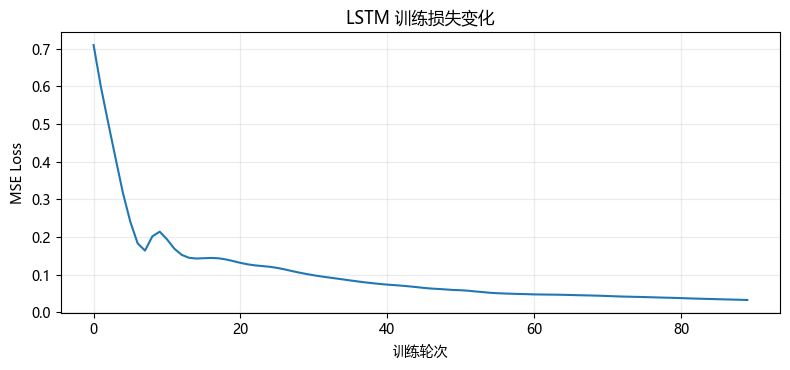

In [23]:
if loss_history:
    plt.figure(figsize=(8, 3.8))
    plt.plot(loss_history)
    plt.title('LSTM 训练损失变化')
    plt.xlabel('训练轮次')
    plt.ylabel('MSE Loss')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'LSTM训练损失.png', dpi=160)
    plt.show()

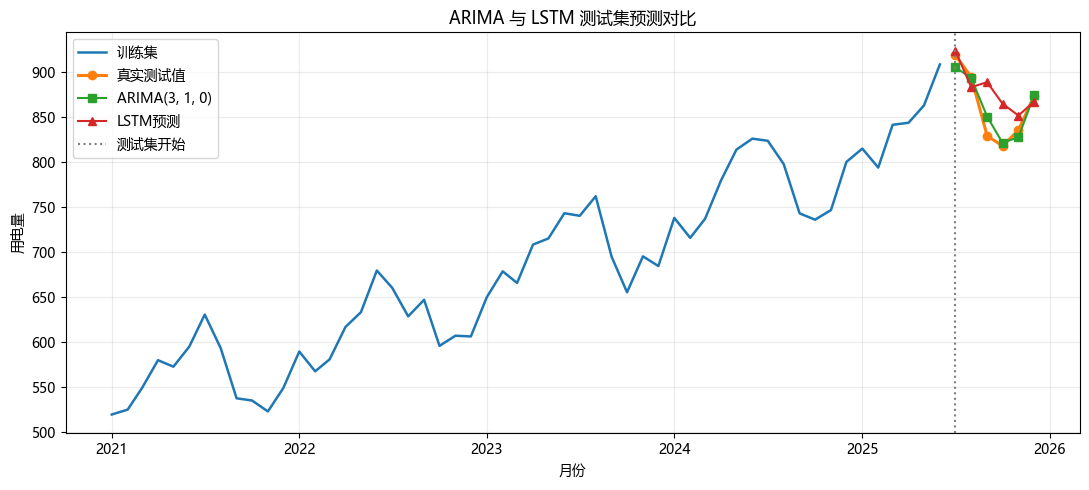

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(train_series.index, train_series.values, label='训练集', linewidth=1.8)
plt.plot(test_series.index, test_series.values, marker='o', linewidth=2.2, label='真实测试值')
plt.plot(arima_forecast.index, arima_forecast.values, marker='s', label=f'ARIMA{best_order}')
plt.plot(lstm_forecast.index, lstm_forecast.values, marker='^', label='LSTM预测')
plt.axvline(test_series.index[0], color='gray', linestyle=':', label='测试集开始')
plt.title('ARIMA 与 LSTM 测试集预测对比')
plt.xlabel('月份')
plt.ylabel('用电量')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ARIMA与LSTM预测对比.png', dpi=160)
plt.show()

## 7. GM(1,1) 灰色预测模型

GM(1,1) 适合小样本、单变量、趋势较明显的数据。

其白化微分方程为：

$$
\frac{dx^{(1)}}{dt}+a x^{(1)}=b
$$

### 7.1 读取 GM(1,1) 小样本数据

这里使用年度能源消费量作为示例，目的是展示 GM(1,1) 对少量趋势数据的处理流程。

In [25]:
gm = pd.read_csv(GM_DATA_PATH, encoding='utf-8-sig')
gm

,年份,能源消费量
0,2017,5420.0
1,2018,5685.0
2,2019,5940.0
3,2020,6210.0
4,2021,6525.0
5,2022,6810.0
6,2023,7135.0
7,2024,7460.0


### 7.2 定义 GM(1,1) 模型

核心步骤包括一次累加生成、构造背景值、最小二乘估计参数，以及从累加序列还原到原始序列。

In [26]:
def gm11(x0, predict_n=3):
    x0 = np.array(x0, dtype=float)
    n = len(x0)

    # 1. 一次累加生成，让小样本序列的趋势更平滑
    x1 = np.cumsum(x0)
    z1 = 0.5 * (x1[:-1] + x1[1:])  # 背景值：相邻累加值的平均

    # 2. 构造最小二乘方程，估计 GM(1,1) 参数 a 和 b
    B = np.column_stack((-z1, np.ones(n - 1)))
    Y = x0[1:]
    a, b = np.linalg.lstsq(B, Y, rcond=None)[0]

    # 3. 时间响应函数：先预测累加序列 x^(1)
    def x1_hat(k):
        return (x0[0] - b / a) * np.exp(-a * k) + b / a

    x1_pred = np.array([x1_hat(k) for k in range(n + predict_n)])

    # 4. 差分还原：从累加预测值回到原始序列尺度
    x0_pred = np.empty_like(x1_pred)
    x0_pred[0] = x0[0]
    x0_pred[1:] = np.diff(x1_pred)
    return a, b, x0_pred

### 7.3 预测并还原结果

GM(1,1) 的预测先发生在累加序列上，再通过差分还原到原始数据尺度。

In [27]:
a, b, gm_pred = gm11(gm['能源消费量'], predict_n=3)
future_years = np.arange(gm['年份'].iloc[0], gm['年份'].iloc[-1] + 4)

gm_result = pd.DataFrame({'年份': future_years, 'GM11拟合预测值': gm_pred.round(2)})
gm_result['实际值'] = np.nan
gm_result.loc[:len(gm) - 1, '实际值'] = gm['能源消费量'].values
gm_result

,年份,GM11拟合预测值,实际值
0,2017,5420.00,5420.0
1,2018,5679.13,5685.0
2,2019,5943.45,5940.0
3,2020,6220.07,6210.0
4,2021,6509.57,6525.0
5,2022,6812.54,6810.0
6,2023,7129.61,7135.0
7,2024,7461.44,7460.0
8,2025,7808.71,NaN
9,2026,8172.14,NaN


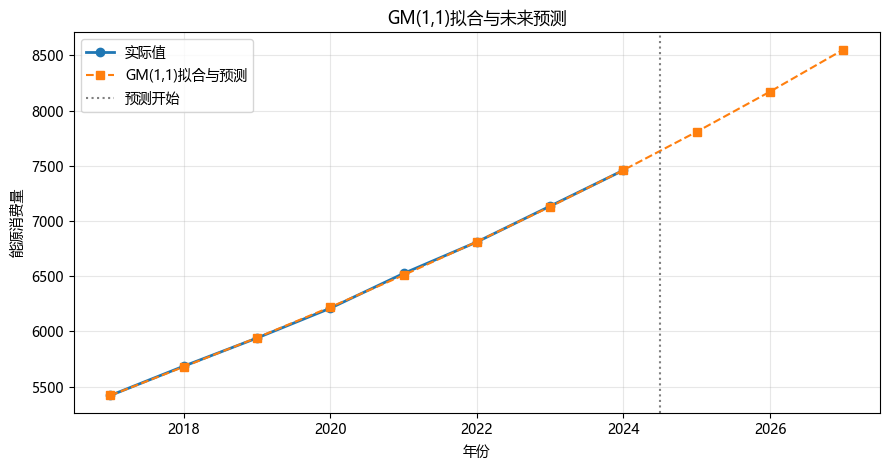

In [28]:
plt.figure(figsize=(9, 4.8))
plt.plot(gm['年份'], gm['能源消费量'], marker='o', linewidth=2, label='实际值')
plt.plot(future_years, gm_pred, marker='s', linestyle='--', label='GM(1,1)拟合与预测')
plt.axvline(gm['年份'].iloc[-1] + 0.5, linestyle=':', color='gray', label='预测开始')
plt.title('GM(1,1)拟合与未来预测')
plt.xlabel('年份')
plt.ylabel('能源消费量')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'GM11拟合与预测.png', dpi=160)
plt.show()

gm_result.to_csv(OUT_DIR / 'GM11拟合预测结果.csv', index=False, encoding='utf-8-sig')

## 8. 多模型结果比较

这里比较的是同一月度用电量测试集上的模型：朴素预测、移动平均、指数平滑、ARIMA 思路和 LSTM。GM(1,1) 使用的是另一份年度小样本数据，因此不与月度测试集直接放入同一误差表。

In [29]:
lstm_metric = pd.DataFrame([
    {'模型': 'LSTM预测', **forecast_metrics(test_series, lstm_forecast)}
])

combined_metrics = pd.concat([metric_df, lstm_metric], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
combined_metrics.to_csv(OUT_DIR / '第七讲单变量模型误差汇总.csv', index=False, encoding='utf-8-sig')
combined_metrics.round(3)

,模型,MAE,RMSE,MAPE_%
0,"ARIMA(3, 1, 0)",7.968,10.883,0.932
1,LSTM预测,24.166,32.122,2.893
2,指数平滑,33.950,36.773,3.929
3,3期移动平均,33.950,38.146,3.978
4,朴素预测,50.350,59.602,6.012


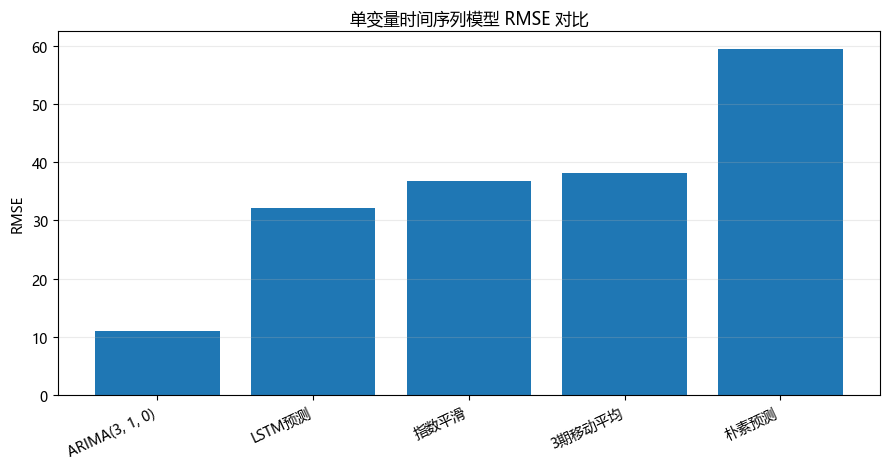

In [30]:
plt.figure(figsize=(9, 4.8))
plt.bar(combined_metrics['模型'], combined_metrics['RMSE'])
plt.ylabel('RMSE')
plt.title('单变量时间序列模型 RMSE 对比')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / '单变量模型RMSE对比.png', dpi=160)
plt.show()

## 9. 论文写作提示

论文中应说明数据频率、训练测试划分、模型参数选择、误差指标和适用边界：

- 平滑模型适合作为简单基线；
- ARIMA 思路强调差分、自相关和残差诊断；
- LSTM 强调滑动窗口和非线性序列学习，但需要用误差证明必要性；
- GM(1,1) 适合小样本趋势数据，不应和不同频率的数据强行比较。

模型选择不是看名称是否复杂，而是看数据结构、误差表现和解释需求是否匹配。

## 课后小作业：比较 ARIMA 与 LSTM

请基于 `combined_metrics` 完成下面任务：

1. 找出 RMSE 最低的模型；
2. 比较 ARIMA 思路和 LSTM 的 MAE、RMSE、MAPE；
3. 判断当前数据是否有必要使用 LSTM；
4. 写出一句适合放入论文的模型选择说明。

In [31]:
# 小作业解答
display(combined_metrics.round(3))

best_overall = combined_metrics.iloc[0]
arima_name = [name for name in combined_metrics['模型'] if name.startswith('ARIMA')][0]
arima_row = combined_metrics[combined_metrics['模型'] == arima_name].iloc[0]
lstm_row = combined_metrics[combined_metrics['模型'] == 'LSTM预测'].iloc[0]

print(f"整体 RMSE 最低的模型：{best_overall['模型']}，RMSE={best_overall['RMSE']:.3f}。")
print(f"ARIMA 思路 RMSE={arima_row['RMSE']:.3f}，LSTM RMSE={lstm_row['RMSE']:.3f}。")

if lstm_row['RMSE'] < arima_row['RMSE']:
    print('结论：LSTM 在测试集上误差更低，可以作为主要预测模型或稳健性对照。')
else:
    print('结论：当前样本下 ARIMA 思路已经较稳健，LSTM 可作为拓展模型，不必强行作为主模型。')

,模型,MAE,RMSE,MAPE_%
0,"ARIMA(3, 1, 0)",7.968,10.883,0.932
1,LSTM预测,24.166,32.122,2.893
2,指数平滑,33.950,36.773,3.929
3,3期移动平均,33.950,38.146,3.978
4,朴素预测,50.350,59.602,6.012


整体 RMSE 最低的模型：ARIMA(3, 1, 0)，RMSE=10.883。
ARIMA 思路 RMSE=10.883，LSTM RMSE=32.122。
结论：当前样本下 ARIMA 思路已经较稳健，LSTM 可作为拓展模型，不必强行作为主模型。
